## Exploratory Data Analysis-(EDA)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
!pip install openpyxl

In [3]:
# Import pandas and ensure openpyxl is available
import pandas as pd

# Note: Make sure openpyxl is installed by running:
# conda install openpyxl  OR  pip install openpyxl

# Read Excel File
df = pd.read_excel('PJMW_MW_Hourly.xlsx')

In [4]:
# First 5 columns
df.head()

,Datetime,PJMW_MW
0,2002-12-31 01:00:00,5077
1,2002-12-31 02:00:00,4939
2,2002-12-31 03:00:00,4885
3,2002-12-31 04:00:00,4857
4,2002-12-31 05:00:00,4930


In [5]:
# Last 5 columns
df.tail()

,Datetime,PJMW_MW
143201,2018-01-01 20:00:00,8401
143202,2018-01-01 21:00:00,8373
143203,2018-01-01 22:00:00,8238
143204,2018-01-01 23:00:00,7958
143205,2018-01-02 00:00:00,7691


In [6]:
# Dataset columns
df.columns

Index(['Datetime', 'PJMW_MW'], dtype='object')

In [7]:
# Dataset shape
print(df.shape)

(143206, 2)


In [8]:
# data type 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143206 entries, 0 to 143205
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   Datetime  143206 non-null  datetime64[ns]
 1   PJMW_MW   143206 non-null  int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 2.2 MB


In [9]:
# Statistical Summary
df.describe()

,Datetime,PJMW_MW
count,143206,143206.000000
mean,2010-06-02 03:39:50.656816128,5602.375089
min,2002-04-01 01:00:00,487.000000
25%,2006-05-02 03:15:00,4907.000000
50%,2010-06-02 04:30:00,5530.000000
75%,2014-07-03 06:45:00,6252.000000
max,2018-08-03 00:00:00,9594.000000
std,NaN,979.142872


In [10]:
# Missing values
df.isnull().sum()

Datetime    0
PJMW_MW     0
dtype: int64

In [11]:

df['Datetime'] = pd.to_datetime(df['Datetime'])  # convert date time
df = df.sort_values('Datetime')                  # sort chronologically(oldest to newest)
df.set_index('Datetime', inplace=True)           # make datetime the index
df.head()

,PJMW_MW
Datetime,
2002-04-01 01:00:00,4374
2002-04-01 02:00:00,4306
2002-04-01 03:00:00,4322
2002-04-01 04:00:00,4359
2002-04-01 05:00:00,4436


### Overall Time Series Visualization

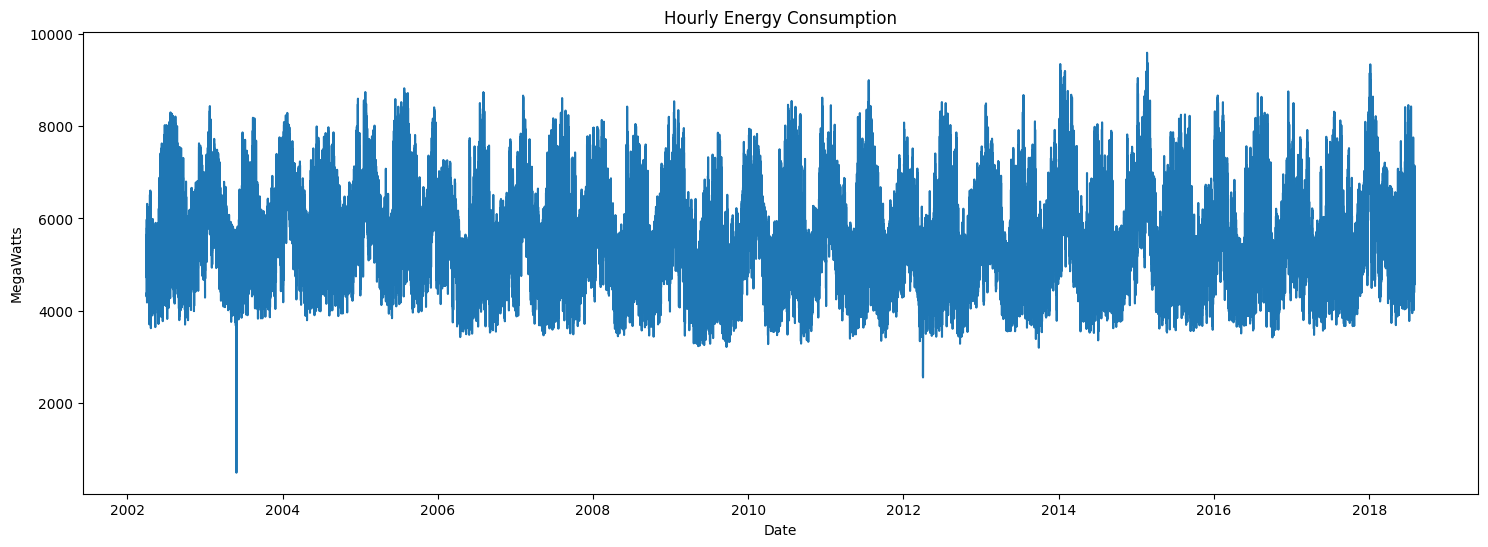

In [12]:
# Energy consumption over time

plt.figure(figsize=(18,6))

plt.plot(df['PJMW_MW'])
plt.title('Hourly Energy Consumption')
plt.xlabel('Date')
plt.ylabel('MegaWatts')

plt.show()

#### Distribution of energy consumption

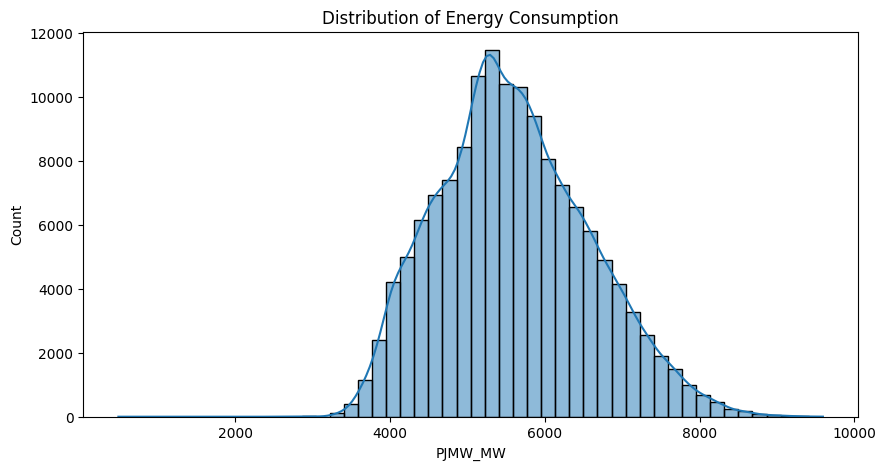

In [13]:
# Histplot

plt.figure(figsize=(10,5))

sns.histplot(df['PJMW_MW'],
            bins=50,
            kde=True
            )
plt.title('Distribution of Energy Consumption')

plt.show()

#### Boxplot for Outlier Detection

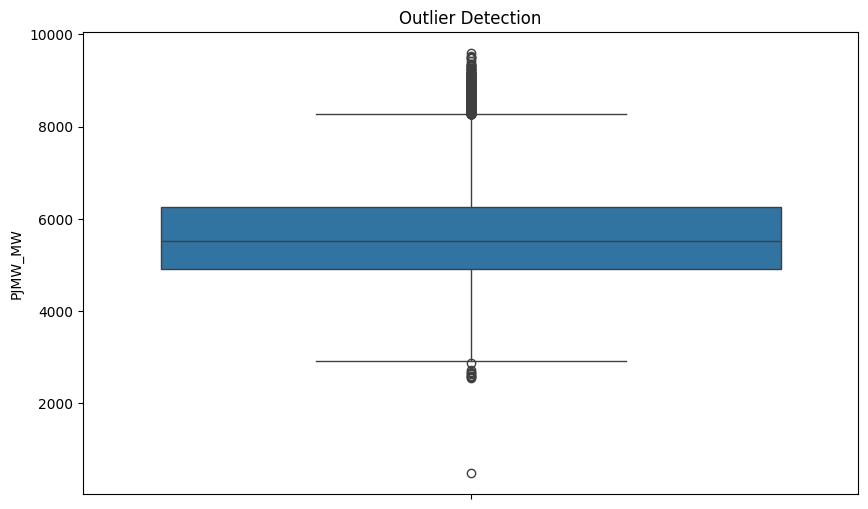

In [14]:
# Boxplot

plt.figure(figsize=(10,6))

sns.boxplot(y=df['PJMW_MW'])
plt.title('Outlier Detection')

plt.show()

### Feature Engineering

In [15]:
# Feature Extraction

df['hour'] = df.index.hour
df['dayofweek'] = df.index.dayofweek
df['month'] = df.index.month
df['quarter'] = df.index.quarter
df['year'] = df.index.year
df['dayofyear'] = df.index.dayofyear
df['day_name'] = df.index.day_name()

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 143206 entries, 2002-04-01 01:00:00 to 2018-08-03 00:00:00
Data columns (total 8 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   PJMW_MW    143206 non-null  int64 
 1   hour       143206 non-null  int32 
 2   dayofweek  143206 non-null  int32 
 3   month      143206 non-null  int32 
 4   quarter    143206 non-null  int32 
 5   year       143206 non-null  int32 
 6   dayofyear  143206 non-null  int32 
 7   day_name   143206 non-null  object
dtypes: int32(6), int64(1), object(1)
memory usage: 6.6+ MB


In [17]:
df.head()

,PJMW_MW,hour,dayofweek,month,quarter,year,dayofyear,day_name
Datetime,,,,,,,,
2002-04-01 01:00:00,4374,1,0,4,2,2002,91,Monday
2002-04-01 02:00:00,4306,2,0,4,2,2002,91,Monday
2002-04-01 03:00:00,4322,3,0,4,2,2002,91,Monday
2002-04-01 04:00:00,4359,4,0,4,2,2002,91,Monday
2002-04-01 05:00:00,4436,5,0,4,2,2002,91,Monday


### Hourly Analysis

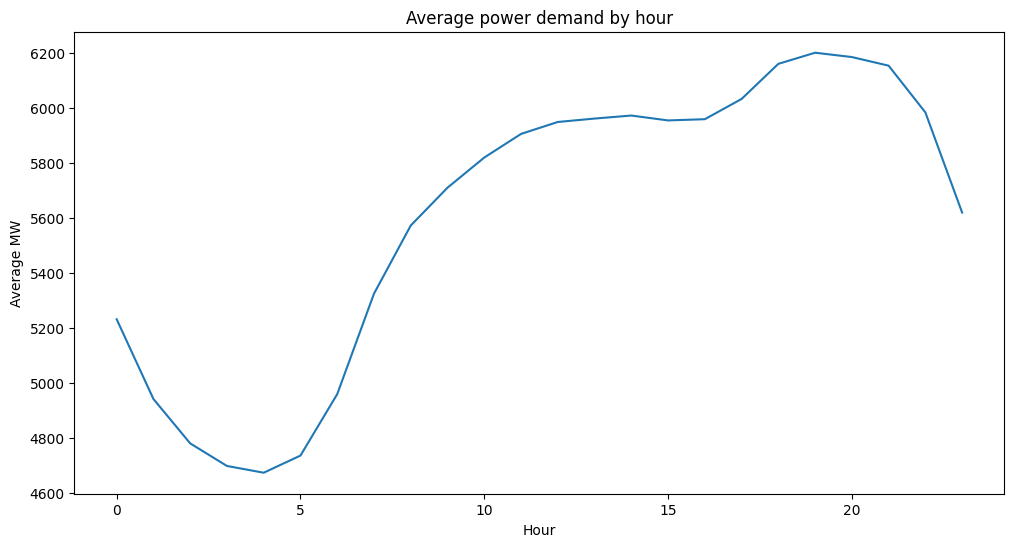

In [18]:
hourly_avg = df.groupby('hour')['PJMW_MW'].mean()

plt.figure(figsize=(12,6))

hourly_avg.plot()
plt.title('Average power demand by hour')
plt.xlabel('Hour')
plt.ylabel('Average MW')

plt.show()

### Week Trend Analysis

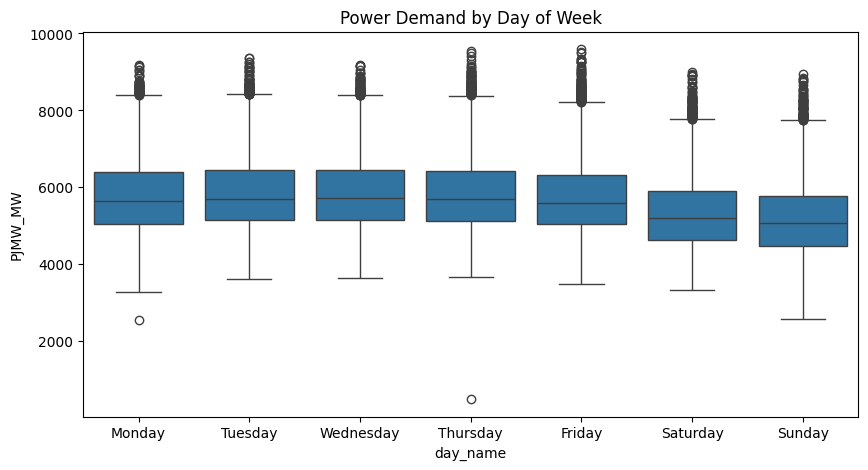

In [19]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x='day_name',
    y='PJMW_MW',
    data=df
)

plt.title('Power Demand by Day of Week')

plt.show()

### Monthly Trend Analysis

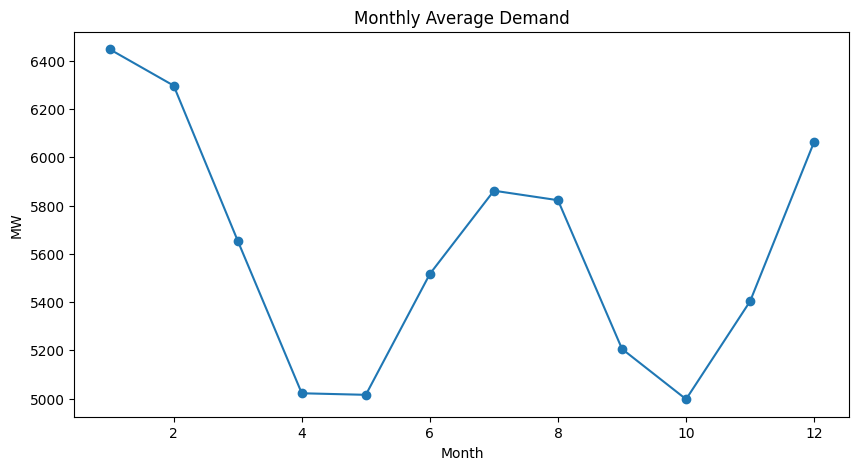

In [20]:
monthly_avg = df.groupby('month')['PJMW_MW'].mean()

plt.figure(figsize=(10,5))

monthly_avg.plot(marker='o')

plt.title("Monthly Average Demand")

plt.xlabel("Month")
plt.ylabel("MW")

plt.show()

### Yearly trend analysis

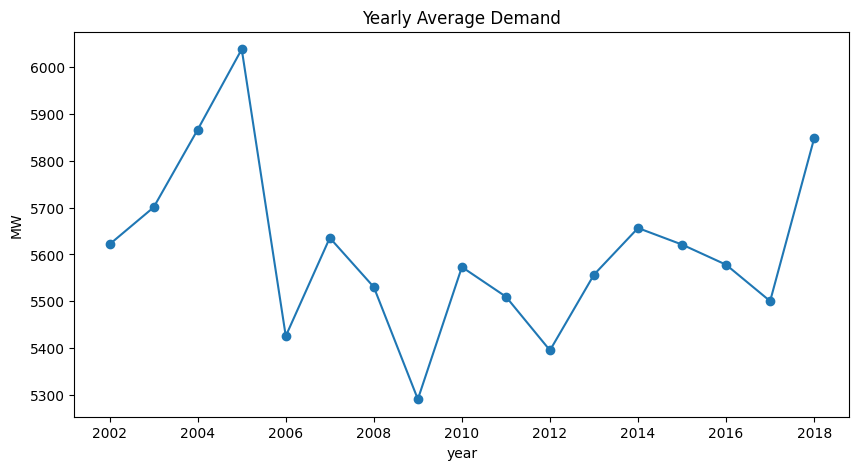

In [21]:
yearly_avg = df.groupby('year')['PJMW_MW'].mean()

plt.figure(figsize=(10,5))

yearly_avg.plot(marker='o')
plt.title("Yearly Average Demand")
plt.ylabel("MW")

plt.show()

### Seasonal Analysis

In [22]:
summer = df[df['month'].isin([6,7,8])]
winter = df[df['month'].isin([12,1,2])]

print("Summer Avg Demand:",summer['PJMW_MW'].mean())

print("Winter Avg Demand:",winter['PJMW_MW'].mean())

Summer Avg Demand: 5734.206129041014
Winter Avg Demand: 6268.813850815178


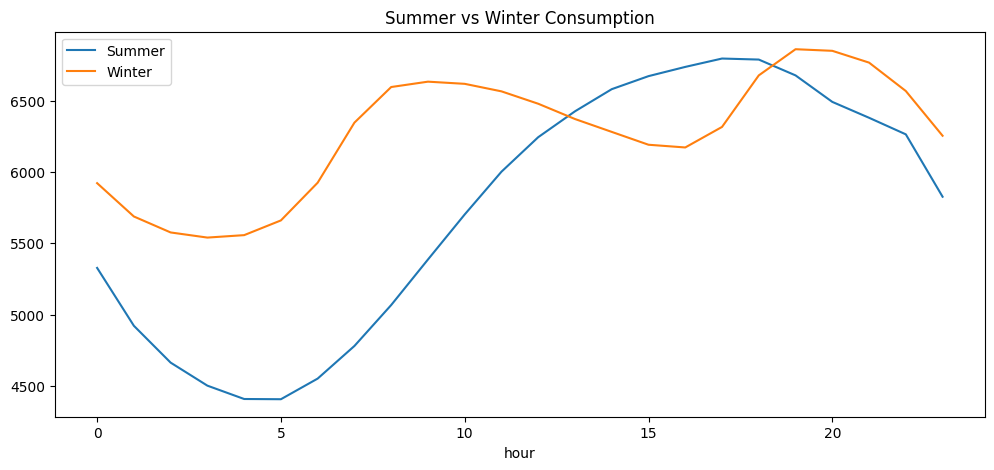

In [23]:
plt.figure(figsize=(12,5))

summer.groupby('hour')['PJMW_MW'].mean().plot(label='Summer')

winter.groupby('hour')['PJMW_MW'].mean().plot(label='Winter')

plt.legend()
plt.title('Summer vs Winter Consumption')
plt.show()

### Rolling Average

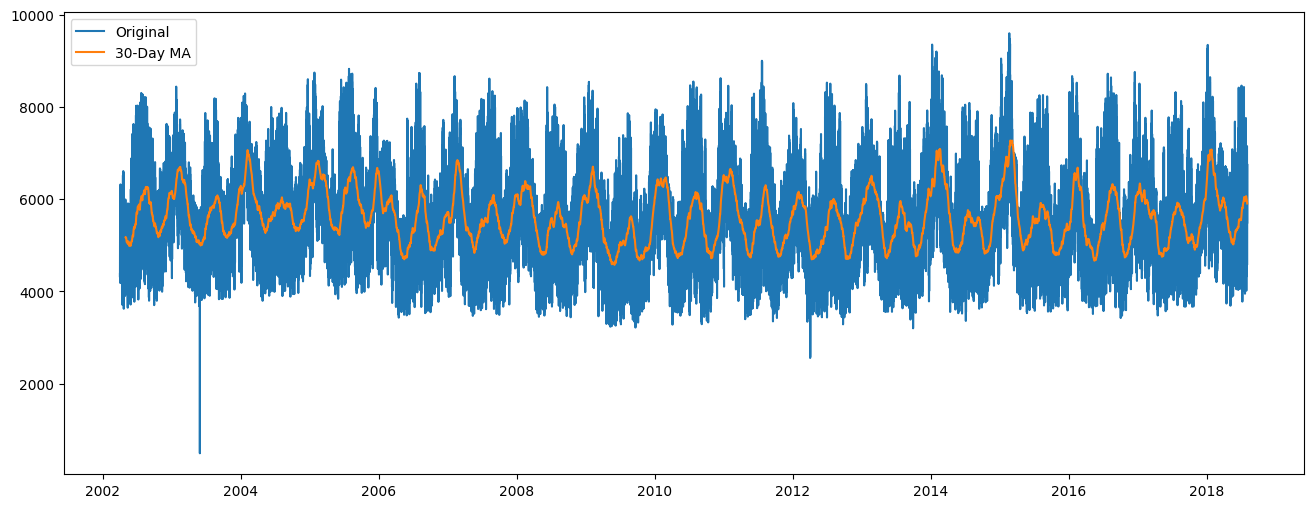

In [24]:
df['rolling_30day'] = df['PJMW_MW'].rolling(24*30).mean()

plt.figure(figsize=(16,6))

plt.plot(df['PJMW_MW'],
         label='Original'
        )
plt.plot(df['rolling_30day'],
         label='30-Day MA'
        )
plt.legend()
plt.show()

### Correlation Analysis

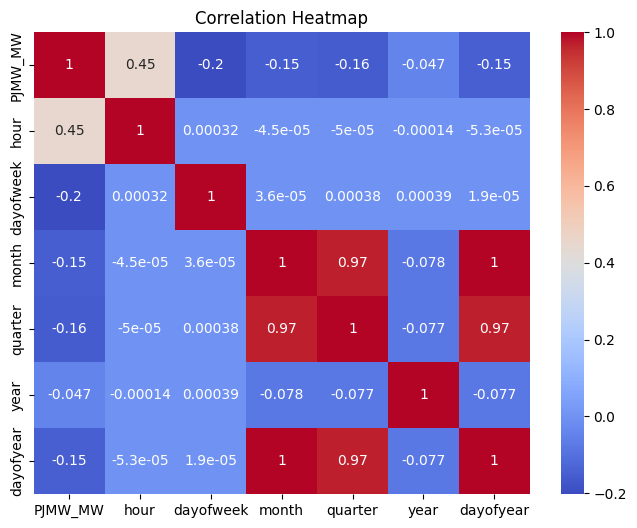

In [25]:
cols = ['PJMW_MW', 'hour', 'dayofweek', 'month', 'quarter', 'year', 'dayofyear']

plt.figure(figsize=(8,6))

sns.heatmap(df[cols].corr(),
           annot=True,
           cmap='coolwarm')
plt.title('Correlation Heatmap')

plt.show()

### LAG Features

In [26]:
df['lag24'] = df['PJMW_MW'].shift(24)           # lag24 (same hour previous day)
df['lag48'] = df['PJMW_MW'].shift(48)           # lag48 (same hour two days ago)
df['lag168'] = df['PJMW_MW'].shift(168)         # lag168 (same hour previous week)

df[['PJMW_MW',
    'lag24',
    'lag48',
    'lag168']].head()

,PJMW_MW,lag24,lag48,lag168
Datetime,,,,
2002-04-01 01:00:00,4374,NaN,NaN,NaN
2002-04-01 02:00:00,4306,NaN,NaN,NaN
2002-04-01 03:00:00,4322,NaN,NaN,NaN
2002-04-01 04:00:00,4359,NaN,NaN,NaN
2002-04-01 05:00:00,4436,NaN,NaN,NaN


#### Rolling features

In [27]:
df['rolling24_mean'] = df['PJMW_MW'].rolling(24).mean()
df['rolling168_mean'] = df['PJMW_MW'].rolling(168).mean()

In [28]:
df.drop('day_name', axis=1, inplace=True) # day_name is useful for EDA and visualization only
df.dropna(inplace=True)

In [29]:
df.head() 

,PJMW_MW,hour,dayofweek,month,quarter,year,dayofyear,rolling_30day,lag24,lag48,lag168,rolling24_mean,rolling168_mean
Datetime,,,,,,,,,,,,,
2002-05-01 01:00:00,4503,1,2,5,2,2002,121,5169.756944,4755.0,4075.0,4827.0,5206.750000,5032.523810
2002-05-01 02:00:00,4418,2,2,5,2,2002,121,5169.818056,4599.0,3990.0,4738.0,5199.208333,5030.619048
2002-05-01 03:00:00,4310,3,2,5,2,2002,121,5169.823611,4528.0,3999.0,4711.0,5190.125000,5028.232143
2002-05-01 04:00:00,4282,4,2,5,2,2002,121,5169.768056,4555.0,4016.0,4743.0,5178.750000,5025.488095
2002-05-01 05:00:00,4431,5,2,5,2,2002,121,5169.868056,4654.0,4109.0,4912.0,5169.458333,5022.625000


#### Checking duplicate timestamps

In [30]:
# print("Duplicate timestamps:", df.index.duplicated().sum())

In [31]:
# print(df.index[df.index.duplicated()])

In [32]:
# df = df[~df.index.duplicated(keep='first')]

In [33]:
df = df.groupby(df.index).mean()

In [34]:
# print(df.index.freq)
# print(df.index.inferred_freq)
# print(df.index.duplicated().sum())

In [35]:
# print(df[df.isna().any(axis=1)].head())

In [36]:
# print(df.isna().sum())

In [37]:
df = df.dropna()

## Model Building

#### Train Test Split

In [38]:
from sklearn.model_selection import train_test_split

# Features and Target
X = df.drop('PJMW_MW', axis=1)
y = df['PJMW_MW']

# Chronological Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

In [39]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((113986, 12), (28497, 12), (113986,), (28497,))

#### Scaling

In [40]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Model-1 Linear Regression

In [41]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train_scaled, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


#### Prediction

In [42]:
lr_pred = lr_model.predict(X_test_scaled)

#### Evaluation

In [43]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [44]:
lr_mae = mean_absolute_error(y_test, lr_pred)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))

lr_r2 =  r2_score(y_test, lr_pred)

print("Linear Regression")
print("MAE:", lr_mae)
print("RMSE:", lr_rmse)
print("R2:", lr_r2)

Linear Regression
MAE: 289.7040583762923
RMSE: 371.35813411527675
R2: 0.8606246957600351


#### Visualization Plot

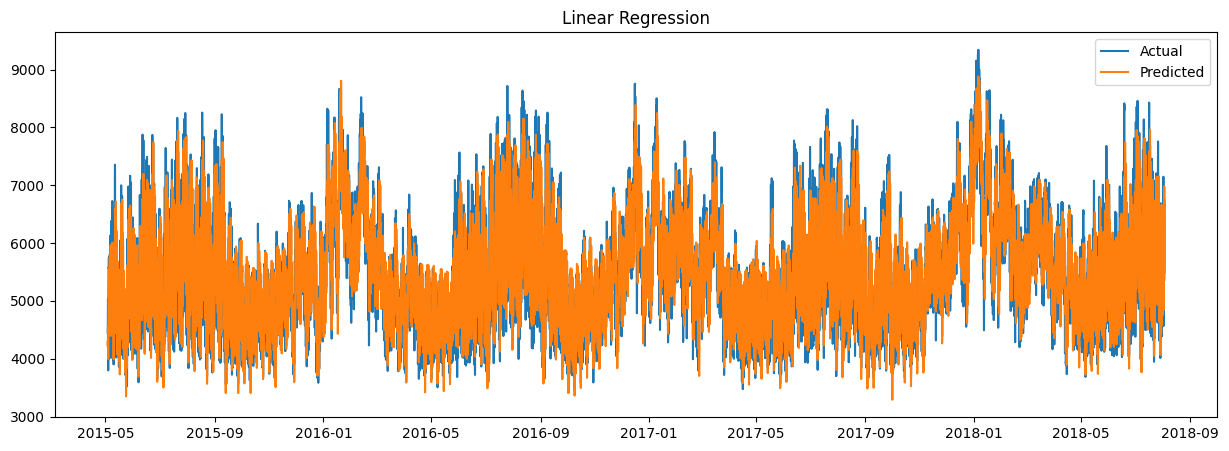

In [45]:
plt.figure(figsize=(15,5))
plt.plot(y_test.index, y_test, label='Actual')
plt.plot(y_test.index, lr_pred, label='Predicted')
plt.title('Linear Regression')
plt.legend()
plt.show()

### Model-2 Random Forest

In [46]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=12,
    min_samples_leaf=5,
    n_jobs=1,
    random_state=42
)

rf_model.fit(X_train_scaled, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,12
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


#### Prediction

In [47]:
rf_pred = rf_model.predict(X_test_scaled)

#### Evaluation

In [48]:
rf_mae = mean_absolute_error(y_test, rf_pred)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

rf_r2 =  r2_score(y_test, rf_pred)

print("Random Forest")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R2:", rf_r2)

Random Forest
MAE: 235.23771329411434
RMSE: 313.70570543618084
R2: 0.9005408413398776


#### Visualization Plot

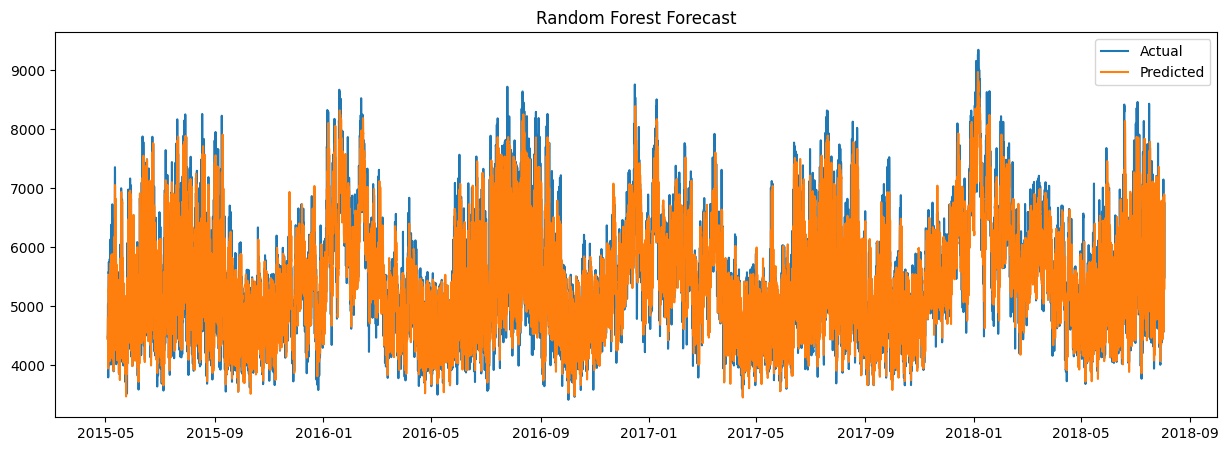

In [49]:
plt.figure(figsize=(15,5))
plt.plot(y_test.index, y_test, label='Actual')
plt.plot(y_test.index, rf_pred, label='Predicted')
plt.title('Random Forest Forecast')
plt.legend()
plt.show()

### Model-3 XGBoost

In [50]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb_model.fit(X_train_scaled, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


#### Prediction

In [51]:
xgb_pred = xgb_model.predict(X_test_scaled)

#### Evaluation

In [52]:
xgb_mae = mean_absolute_error(y_test, xgb_pred)

xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))

xgb_r2 =  r2_score(y_test, xgb_pred)

print("XGBoost")
print("MAE:", xgb_mae)
print("RMSE:", xgb_rmse)
print("R2:", xgb_r2)

XGBoost
MAE: 209.60276886156603
RMSE: 276.88490023351676
R2: 0.9225184159142699


#### Visualization Plot

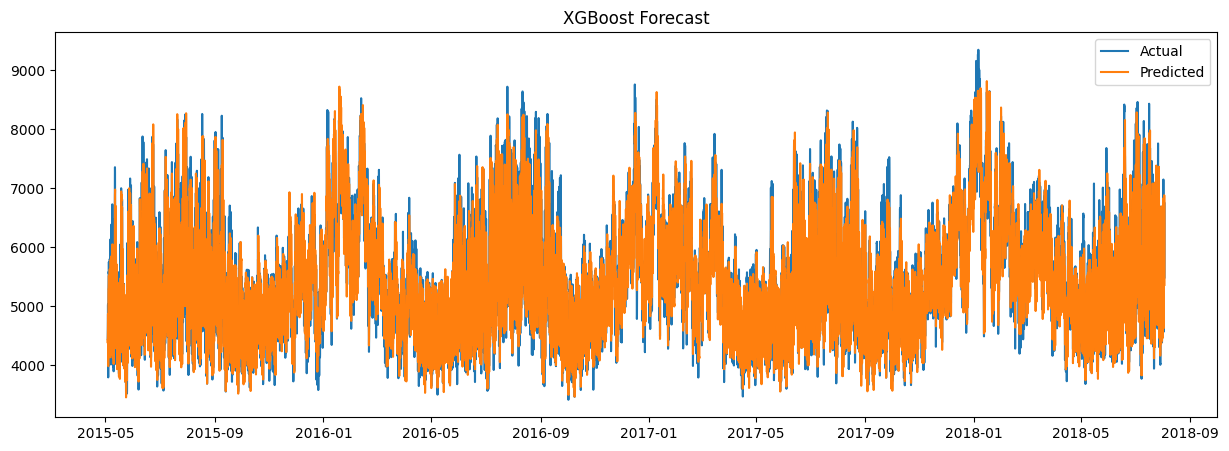

In [53]:
plt.figure(figsize=(15,5))
plt.plot(y_test.index, y_test, label='Actual')
plt.plot(y_test.index, xgb_pred, label='Predicted')
plt.title('XGBoost Forecast')
plt.legend()
plt.show()

#### Model-4 Holt-Winters

#### Train-Test-Split

In [54]:
train_hw, test_hw = train_test_split(
    df['PJMW_MW'],
    test_size=0.2,
    random_state=42
)

In [55]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

#### Model Building

In [56]:
hw_model = ExponentialSmoothing(
    train_hw,
    trend='add',
    seasonal='add',
    seasonal_periods=24
)

hw_fit = hw_model.fit()

/opt/anaconda3/envs/ann_env/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/ann_env/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/ann_env/lib/python3.10/site-packages/statsmodels/tsa/holtwinters/model.py:85: RuntimeWarning: overflow encountered in matmul
  return err.T @ err


#### Prediction

In [57]:
hw_pred = hw_fit.forecast(len(test_hw))

/opt/anaconda3/envs/ann_env/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/anaconda3/envs/ann_env/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


#### Evaluation

In [58]:
hw_mae = mean_absolute_error(test_hw, hw_pred)

hw_rmse = np.sqrt(mean_squared_error(test_hw, hw_pred))

hw_r2 =  r2_score(test_hw, hw_pred)

print("Holt-Winters")
print("MAE:", hw_mae)
print("RMSE:", hw_rmse)
print("R2:", hw_r2)

Holt-Winters
MAE: 792.5506736719528
RMSE: 980.1298890956491
R2: -0.005770766920021764


### Model-5 FB Prophet

In [60]:
!pip install prophet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 4.8 MB/s  0:00:02 eta 0:00:010:0101
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 4.8 MB/s  0:00:00m 4.8 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [prophet]━━━ 4/5 [prophet]]


In [61]:
from prophet import Prophet

# Convert index to column
prophet_df = df[['PJMW_MW']].reset_index()

# Rename columns for Prophet
prophet_df.rename(columns={
    'Datetime': 'ds',
    'PJMW_MW': 'y'
}, inplace=True)

prophet_df.head()

Importing plotly failed. Interactive plots will not work.


,ds,y
0,2002-05-01 01:00:00,4503.0
1,2002-05-01 02:00:00,4418.0
2,2002-05-01 03:00:00,4310.0
3,2002-05-01 04:00:00,4282.0
4,2002-05-01 05:00:00,4431.0


#### Train-Test-Split

In [62]:
train_prophet, test_prophet = train_test_split(
    prophet_df,
    test_size=0.2,
    random_state=42
)

#### Model Build

In [63]:
prophet_model = Prophet()

prophet_model.fit(train_prophet)

21:17:21 - cmdstanpy - INFO - Chain [1] start processing
21:17:49 - cmdstanpy - INFO - Chain [1] done processing


#### Prediction

In [64]:
future = test_prophet[['ds']]

forecast = prophet_model.predict(future)

prophet_pred = forecast['yhat'].values

#### Evaluation

In [65]:
prophet_mae = mean_absolute_error(test_prophet['y'], prophet_pred)

prophet_rmse = np.sqrt(mean_squared_error(test_prophet['y'], prophet_pred))

prophet_r2 =  r2_score(test_prophet['y'], prophet_pred)

print("FB-Prophet")
print("MAE:", prophet_mae)
print("RMSE:", prophet_rmse)
print("R2:", prophet_r2)

FB-Prophet
MAE: 1009.4581939210232
RMSE: 1252.7640509181563
R2: -0.6431238784800728


### Visualization Plots of all Models

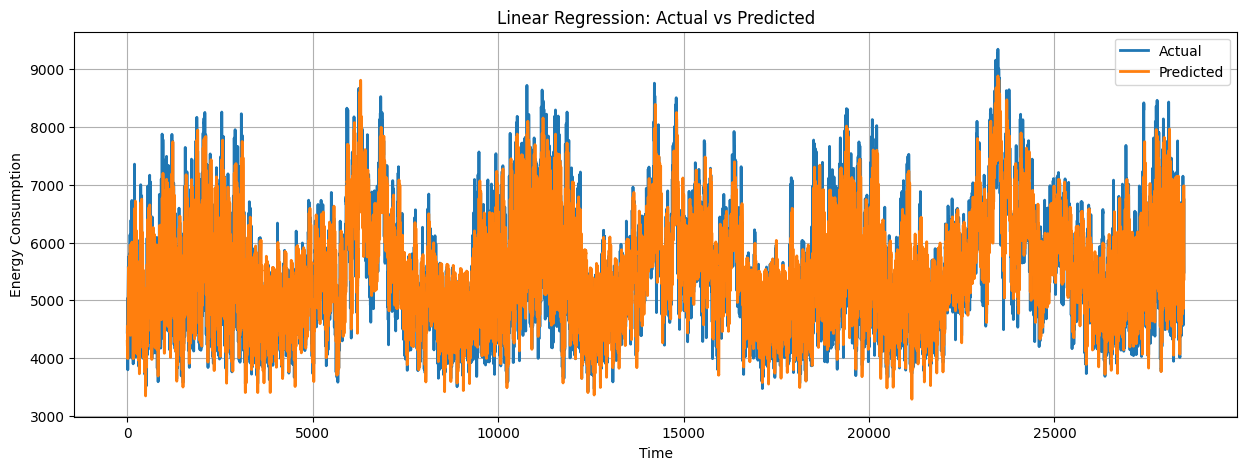

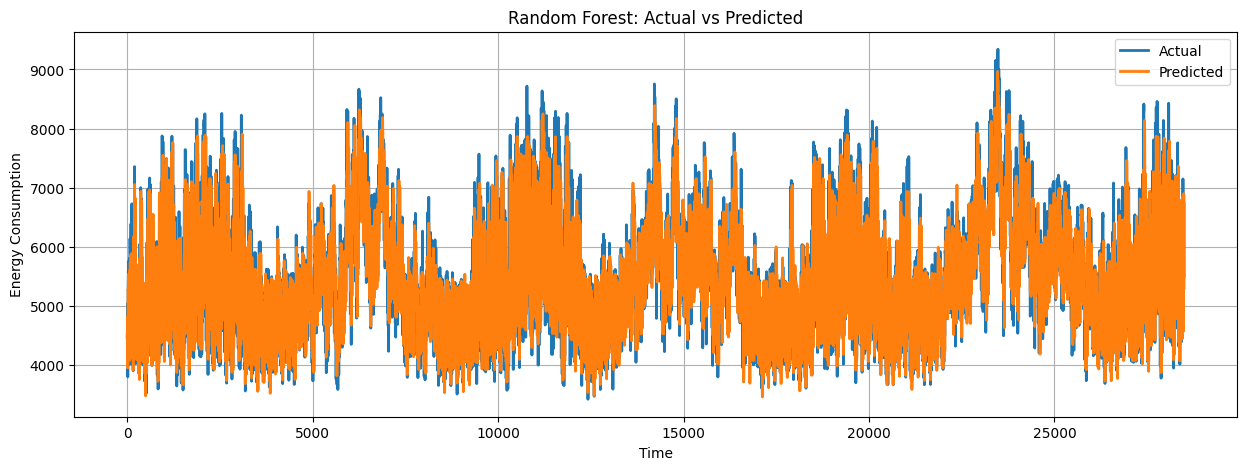

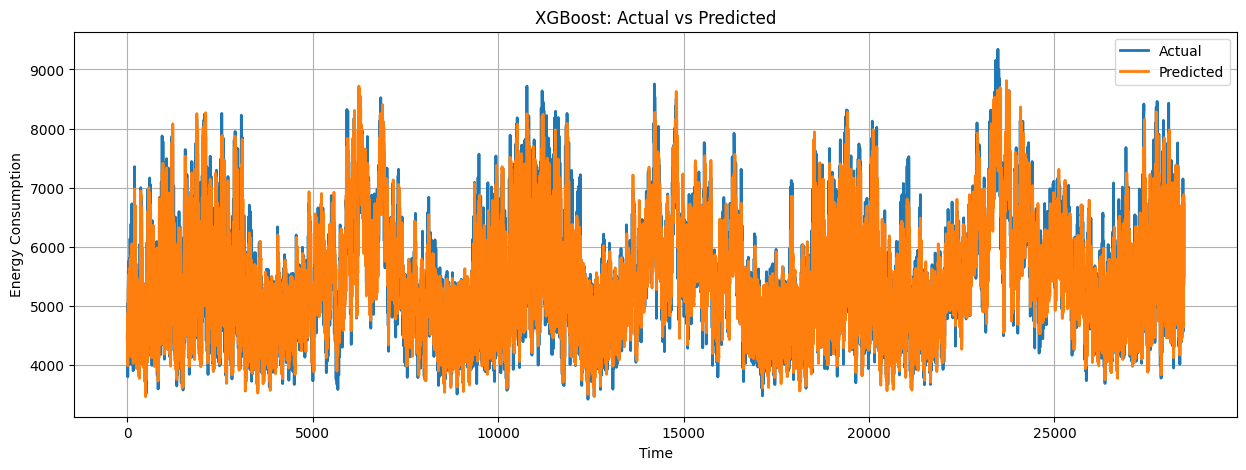

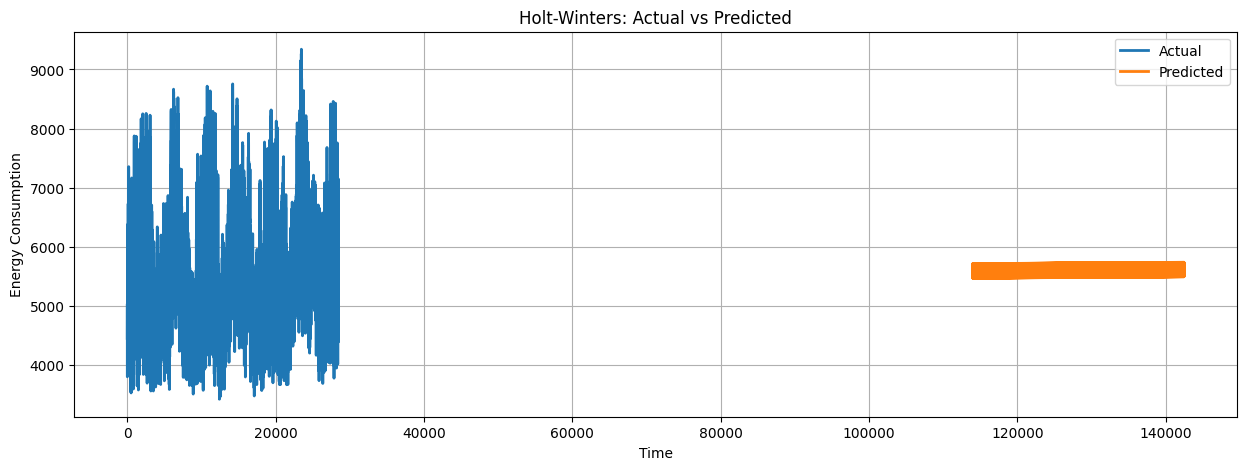

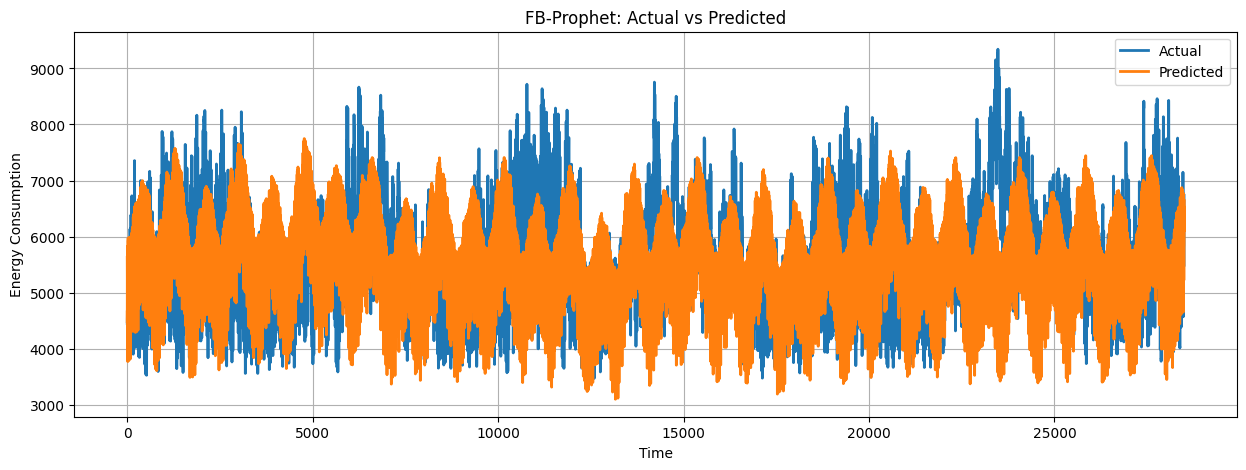

In [66]:

models = {
    "Linear Regression": lr_pred,
    "Random Forest": rf_pred,
    "XGBoost": xgb_pred,
    "Holt-Winters": hw_pred,
    "FB-Prophet": prophet_pred
}

for name, pred in models.items():

    plt.figure(figsize=(15,5))

    plt.plot(y_test.values, label="Actual", linewidth=2)
    plt.plot(pred, label="Predicted", linewidth=2)

    plt.title(f"{name}: Actual vs Predicted")
    plt.xlabel("Time")
    plt.ylabel("Energy Consumption")
    plt.legend()
    plt.grid(True)

    plt.show()

### Comparison Table

In [67]:
# ==============================
# MODEL COMPARISON
# ==============================

print("\n" + "="*90)
print("FINAL RESULTS - ALL MODELS COMPARISON")
print("="*90)

results = {
    'Model': [
        'Linear Regression',
        'Random Forest',
        'XGBoost',
        'FB Prophet',
        'Holt-Winters'
    ],
    'MAE': [
        lr_mae,
        rf_mae,
        xgb_mae,
        prophet_mae,
        hw_mae
    ],
    'RMSE': [
        lr_rmse,
        rf_rmse,
        xgb_rmse,
        prophet_rmse,
        hw_rmse
    ],
    'R2 Score': [
        lr_r2,
        rf_r2,
        xgb_r2,
        prophet_r2,
        hw_r2
    ]
}

results_df = pd.DataFrame(results)

# Sort by MAE (lower is better)
results_df = results_df.sort_values(by='MAE').reset_index(drop=True)

print("\n")
print(results_df.to_string(index=False))

# ==============================
# BEST MODEL
# ==============================

best_model = results_df.iloc[0]

print("\n" + "="*90)
print(f"🏆 BEST MODEL : {best_model['Model']}")
print(f"   MAE       : {best_model['MAE']:.2f}")
print(f"   RMSE      : {best_model['RMSE']:.2f}")
print(f"   R² Score  : {best_model['R2 Score']:.4f}")
print("="*90)

# ==============================
# MODEL RANKING
# ==============================

print("\nMODEL RANKING:\n")

medals = ['🥇', '🥈', '🥉', '4️⃣', '5️⃣']

for idx, row in results_df.iterrows():
    print(
        f"{medals[idx]} {idx+1}. "
        f"{row['Model']:<20}"
        f"MAE: {row['MAE']:10.2f}   "
        f"RMSE: {row['RMSE']:10.2f}   "
        f"R²: {row['R2 Score']:.4f}"
    )

print("="*90)


FINAL RESULTS - ALL MODELS COMPARISON


            Model         MAE        RMSE  R2 Score
          XGBoost  209.602769  276.884900  0.922518
    Random Forest  235.237713  313.705705  0.900541
Linear Regression  289.704058  371.358134  0.860625
     Holt-Winters  792.550674  980.129889 -0.005771
       FB Prophet 1009.458194 1252.764051 -0.643124

🏆 BEST MODEL : XGBoost
   MAE       : 209.60
   RMSE      : 276.88
   R² Score  : 0.9225

MODEL RANKING:

🥇 1. XGBoost             MAE:     209.60   RMSE:     276.88   R²: 0.9225
🥈 2. Random Forest       MAE:     235.24   RMSE:     313.71   R²: 0.9005
🥉 3. Linear Regression   MAE:     289.70   RMSE:     371.36   R²: 0.8606
4️⃣ 4. Holt-Winters        MAE:     792.55   RMSE:     980.13   R²: -0.0058
5️⃣ 5. FB Prophet          MAE:    1009.46   RMSE:    1252.76   R²: -0.6431


### Forecasting Next 30 days

In [68]:
future_hours = 24 * 30

# Use the full dataset as history
history = df.copy()

future_predictions = []

for i in range(future_hours):

    # Next timestamp
    next_time = history.index[-1] + pd.Timedelta(hours=1)

    # Calendar features
    hour = next_time.hour
    dayofweek = next_time.dayofweek
    month = next_time.month
    quarter = next_time.quarter
    year = next_time.year
    dayofyear = next_time.dayofyear

    # Lag features
    lag24 = history['PJMW_MW'].iloc[-24]
    lag48 = history['PJMW_MW'].iloc[-48]
    lag168 = history['PJMW_MW'].iloc[-168]

    # Rolling features
    rolling24_mean = history['PJMW_MW'].iloc[-24:].mean()
    rolling168_mean = history['PJMW_MW'].iloc[-168:].mean()
    rolling_30day = history['PJMW_MW'].iloc[-720:].mean()

    future_row = pd.DataFrame({
        'hour': [hour],
        'dayofweek': [dayofweek],
        'month': [month],
        'quarter': [quarter],
        'year': [year],
        'dayofyear': [dayofyear],
        'rolling_30day': [rolling_30day],
        'lag24': [lag24],
        'lag48': [lag48],
        'lag168': [lag168],
        'rolling24_mean': [rolling24_mean],
        'rolling168_mean': [rolling168_mean]
    })

    # Scale using the scaler fitted on the training data
    future_scaled = scaler.transform(future_row)

    # Predict
    pred = xgb_model.predict(future_scaled)[0]

    future_predictions.append(pred)

    # Append prediction for next iteration
    history.loc[next_time] = {
        'PJMW_MW': pred,
        'hour': hour,
        'dayofweek': dayofweek,
        'month': month,
        'quarter': quarter,
        'year': year,
        'dayofyear': dayofyear,
        'rolling_30day': rolling_30day,
        'lag24': lag24,
        'lag48': lag48,
        'lag168': lag168,
        'rolling24_mean': rolling24_mean,
        'rolling168_mean': rolling168_mean
    }

#### Forecast Dataframe

In [69]:
forecast_xgb = pd.DataFrame({
    'Datetime': pd.date_range(
        start=df.index[-1] + pd.Timedelta(hours=1),
        periods=future_hours,
        freq='h'
    ),
    'Forecast_MW': future_predictions
})

forecast_xgb.head()

,Datetime,Forecast_MW
0,2018-08-03 01:00:00,4925.880859
1,2018-08-03 02:00:00,4717.304688
2,2018-08-03 03:00:00,4646.020020
3,2018-08-03 04:00:00,4555.225586
4,2018-08-03 05:00:00,4576.850098


#### Visualization Plot

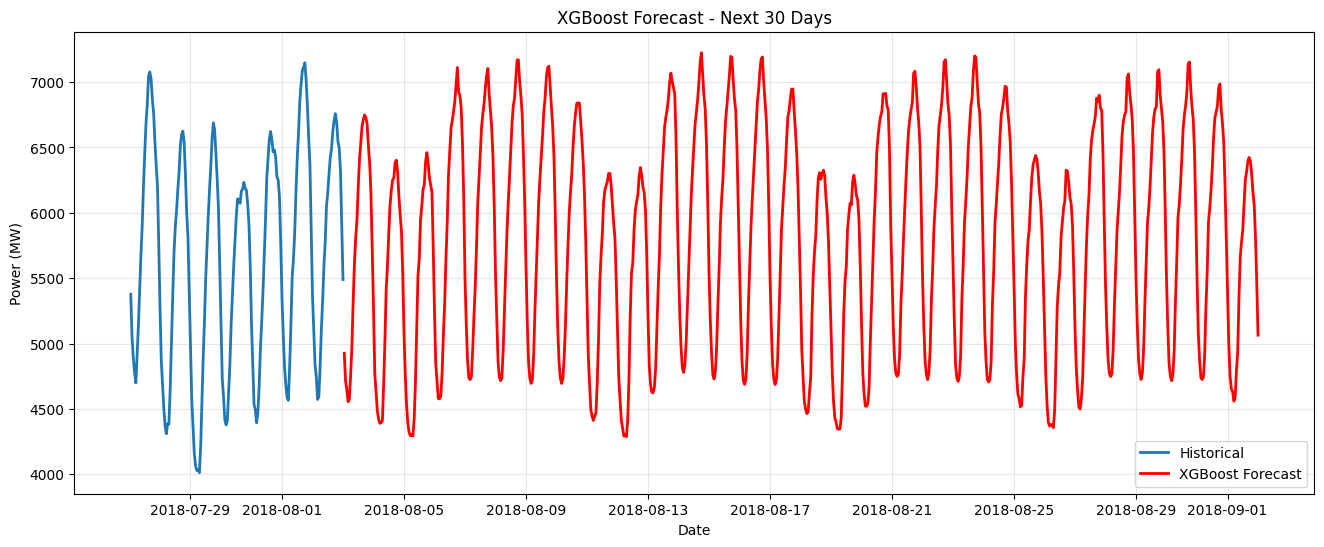

In [70]:
plt.figure(figsize=(16,6))

plt.plot(
    df.index[-24*7:],
    df['PJMW_MW'].tail(24*7),
    label='Historical',
    linewidth=2
)

plt.plot(
    forecast_xgb['Datetime'],
    forecast_xgb['Forecast_MW'],
    color='red',
    linewidth=2,
    label='XGBoost Forecast'
)

plt.title('XGBoost Forecast - Next 30 Days')
plt.xlabel('Date')
plt.ylabel('Power (MW)')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [71]:
import pickle

with open("energy_model.pkl", "wb") as f:
    pickle.dump(xgb_model, f)